# Foldy–Wouthuysen Derivation: The $b_\mu$ SME Coefficient

**MSc Research — Oyewo Temidayo Solomon**  
*Unified Constraint Framework for Exotic Spin-Dependent Interactions*  
University of Ibadan | Supervisor: Prof. O.E. Oyewande

---

## Overview

This notebook derives the nonrelativistic Hamiltonian arising from the CPT-odd,
Lorentz-violating $b_\mu$ coefficient of the Standard Model Extension (SME):

$$\mathcal{L}_b = -b_\mu \bar{\psi} \gamma^\mu \gamma^5 \psi$$

**Steps:**
1. Construct the Dirac-level Hamiltonian $H_b$
2. Classify even/odd operators under $\beta$
3. Apply the Foldy–Wouthuysen generator $S = -i\beta\mathcal{O}/2m$
4. Evaluate $\mathcal{O}^2$ and all BCH commutators to $O(1/m)$
5. Project onto upper components to get $H^\text{NR}$
6. Apply CPT conjugation to obtain the antiparticle Hamiltonian
7. Match to Dobrescu–Mocioiu potentials

**Reference:** Kostelecky & Lane, Phys. Rev. D 60, 116010 (1999), Eq. (4.5).


## 1. Setup — Import Dirac Algebra

In [1]:
import sys, os
import sympy as sp
from sympy import (
    I, Matrix, symbols, sqrt, Rational, simplify, expand,
    zeros, eye, pprint, latex
)

# Correct path resolution for Jupyter
notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

# Import modules
try:
    from dirac_algebra import (
        beta, alpha, gamma, gamma5, Sigma,
        sigma_munu, comm, acomm, is_even, is_odd,
        even_part, odd_part, upper, lower, I4, Z4
    )
    from pauli_matrices import sigma, I2, Z2, H_NR_bmu, cpt_conjugate
    print("Modules loaded.")
except ImportError as e:
    print(f"Import failed: {e}")
    print("Check that dirac_algebra.py and pauli_matrices.py are in:", notebook_dir)
    print("Local modules not found — defining inline...")
    # Inline fallback definitions
    sigma_x = Matrix([[0, 1], [1, 0]])
    sigma_y = Matrix([[0, -I], [I, 0]])
    sigma_z = Matrix([[1, 0], [0, -1]])
    sigma = [sigma_x, sigma_y, sigma_z]
    I2 = eye(2); Z2 = zeros(2,2)
    I4 = eye(4); Z4 = zeros(4,4)
    beta = Matrix([[1,0,0,0],[0,1,0,0],[0,0,-1,0],[0,0,0,-1]])
    alpha = [
        Matrix([[0,0,0,1],[0,0,1,0],[0,1,0,0],[1,0,0,0]]),
        Matrix([[0,0,0,-I],[0,0,I,0],[0,-I,0,0],[I,0,0,0]]),
        Matrix([[0,0,1,0],[0,0,0,-1],[1,0,0,0],[0,-1,0,0]]),
    ]
    gamma5 = Matrix([[0,0,1,0],[0,0,0,1],[1,0,0,0],[0,1,0,0]])
    Sigma = [
        Matrix([[0,1,0,0],[1,0,0,0],[0,0,0,1],[0,0,1,0]]),
        Matrix([[0,-I,0,0],[I,0,0,0],[0,0,0,-I],[0,0,I,0]]),
        Matrix([[1,0,0,0],[0,-1,0,0],[0,0,1,0],[0,0,0,-1]]),
    ]
    def comm(A,B): return A*B - B*A
    def is_even(M): return simplify(beta*M - M*beta) == Z4
    def is_odd(M):  return simplify(beta*M + M*beta) == Z4
    def upper(M):   return M[:2,:2]

print("\nbeta ="); pprint(beta)
print("\ngamma5 ="); pprint(gamma5)


Modules loaded.

beta =
⎡1  0  0   0 ⎤
⎢            ⎥
⎢0  1  0   0 ⎥
⎢            ⎥
⎢0  0  -1  0 ⎥
⎢            ⎥
⎣0  0  0   -1⎦

gamma5 =
⎡0  0  1  0⎤
⎢          ⎥
⎢0  0  0  1⎥
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎣0  1  0  0⎦


## 2. The $b_\mu$ Hamiltonian

The Dirac equation with the SME $b_\mu$ term gives the interaction Hamiltonian:

$$H_b = b_0 \gamma^0 \gamma^5 + b_i \alpha^i \gamma^5$$

Wait — we need to be careful. From $\mathcal{L}_b = -b_\mu\bar\psi\gamma^\mu\gamma^5\psi$, the
Dirac equation reads $(i\not\partial - m - b_\mu\gamma^\mu\gamma^5)\psi = 0$, so:

$$H_b = b_\mu \gamma^0 \gamma^\mu \gamma^5$$

For $\mu=0$: $\gamma^0\gamma^0\gamma^5 = \gamma^5$ (odd)  
For $\mu=i$: $\gamma^0\gamma^i\gamma^5 = \alpha^i\gamma^5$ (even)

**Correction (this revision):** this cell previously claimed $\gamma^0\gamma^i\gamma^5 = \beta\alpha^i\gamma^5 = \Sigma^i\beta$, with a spurious extra factor of $\beta$. Using $\alpha^i \equiv \gamma^0\gamma^i$ directly, $\gamma^0\gamma^i\gamma^5 = \gamma^0(\gamma^0\alpha^i)\gamma^5 = \alpha^i\gamma^5$ — no extra $\beta$. Verified numerically in the next cell: $\gamma^0\gamma^1\gamma^5$ equals $\alpha^1\gamma^5$, **not** $\Sigma^1\beta$ (the two differ, even though $\beta\alpha^1\gamma^5$ separately happens to equal $\Sigma^1\beta$ — a true but irrelevant identity that doesn't describe $\gamma^0\gamma^1\gamma^5$). This bug propagated into the original `H_b_even` construction below and is fixed there too; see the note in §6–7 for what changes as a result.

We decompose: $H_b = \mathcal{O}_b + \mathcal{E}_b$, where $\mathcal{O}_b = b_0\gamma^5$ (odd) and $\mathcal{E}_b = \sum_i b_i\,\alpha^i\gamma^5$ (even — a product of two operators that each anticommute with $\beta$ is itself even).


In [2]:
b0, b1, b2, b3 = symbols('b_0 b_1 b_2 b_3', real=True)
b_spatial = [b1, b2, b3]

# gamma^0 gamma^mu gamma^5 for each mu
g0g0g5 = beta * beta * gamma5  # = gamma5
g0gi_g5 = [beta * gamma[i+1] * gamma5 for i in range(3)]  # gamma^0 gamma^i gamma^5, directly

print("gamma^0 * gamma^0 * gamma^5 (mu=0 contribution, should be gamma5):")
pprint(g0g0g5)
print("\nIs it odd (off-diagonal)?", is_odd(g0g0g5))

print("\ngamma^0 * gamma^1 * gamma^5 (mu=1 contribution, computed directly):")
pprint(g0gi_g5[0])
print("Is it even (block-diagonal)?", is_even(g0gi_g5[0]))

# Correct identity: gamma^0 gamma^i gamma^5 = alpha^i gamma^5 (NOT beta*alpha^i*gamma^5)
print("\nVerify gamma^0*gamma[1]*gamma5 == alpha[0]*gamma5:")
lhs = g0gi_g5[0]
rhs_correct = alpha[0] * gamma5
print("LHS - alpha[0]*gamma5 =", simplify(lhs - rhs_correct))

# The previously-claimed identity (with a spurious extra beta) does NOT match:
rhs_wrong = beta * alpha[0] * gamma5
print("LHS - beta*alpha[0]*gamma5 =", simplify(lhs - rhs_wrong),
      " <- previously (incorrectly) claimed equal; it is not")
print("(Sigma[0]*beta does equal beta*alpha[0]*gamma5 as a standalone identity —")
print(" that part was true — but that quantity is not what gamma^0 gamma^i gamma^5 equals.)")


gamma^0 * gamma^0 * gamma^5 (mu=0 contribution, should be gamma5):
⎡0  0  1  0⎤
⎢          ⎥
⎢0  0  0  1⎥
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎣0  1  0  0⎦

Is it odd (off-diagonal)? True

gamma^0 * gamma^1 * gamma^5 (mu=1 contribution, computed directly):
⎡0  1  0  0⎤
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎢0  0  0  1⎥
⎢          ⎥
⎣0  0  1  0⎦
Is it even (block-diagonal)? True

Verify gamma^0*gamma[1]*gamma5 == alpha[0]*gamma5:
LHS - alpha[0]*gamma5 = Matrix([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
LHS - beta*alpha[0]*gamma5 = Matrix([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 2], [0, 0, 2, 0]])  <- previously (incorrectly) claimed equal; it is not
(Sigma[0]*beta does equal beta*alpha[0]*gamma5 as a standalone identity —
 that part was true — but that quantity is not what gamma^0 gamma^i gamma^5 equals.)


In [3]:
def _msum(terms):
    """Matrix-safe sum (builtin sum() fails: it seeds the accumulator with
    the int 0, and 0 + Matrix is not supported by SymPy)."""
    result = None
    for t in terms:
        result = t if result is None else result + t
    return result

# Full Hamiltonian contribution from b_mu
# Correction (this revision): H_b_even uses alpha^i*gamma5, not Sigma^i*beta
# (see the corrected identity in the cell above).
H_b_odd  = b0 * gamma5                                  # O_b : odd part
H_b_even = _msum([b_spatial[i] * alpha[i] * gamma5      # E_b : even part
                   for i in range(3)])

H_b = H_b_odd + H_b_even

print("Odd part of H_b (O_b = b0 * gamma5):")
pprint(H_b_odd)
print("\nIs O_b odd?", is_odd(H_b_odd))

print("\nEven part of H_b (E_b = b_i alpha^i gamma5):")
pprint(H_b_even)
print("Is E_b even?", is_even(H_b_even))


Odd part of H_b (O_b = b0 * gamma5):
⎡0   0   b₀  0 ⎤
⎢              ⎥
⎢0   0   0   b₀⎥
⎢              ⎥
⎢b₀  0   0   0 ⎥
⎢              ⎥
⎣0   b₀  0   0 ⎦

Is O_b odd? True

Even part of H_b (E_b = b_i alpha^i gamma5):
⎡   b₃      b₁ - ⅈ⋅b₂      0          0    ⎤
⎢                                          ⎥
⎢b₁ + ⅈ⋅b₂     -b₃         0          0    ⎥
⎢                                          ⎥
⎢    0          0         b₃      b₁ - ⅈ⋅b₂⎥
⎢                                          ⎥
⎣    0          0      b₁ + ⅈ⋅b₂     -b₃   ⎦
Is E_b even? True


## 3. Full Hamiltonian and Even/Odd Decomposition

The full Hamiltonian (including free Dirac and EM field terms) is:

$$H = \underbrace{\beta m}_{\mathcal{E}_0} + \underbrace{\boldsymbol{\alpha}\cdot\mathbf{p}}_{\mathcal{O}_0} + \underbrace{e\Phi}_{\mathcal{E}_\Phi} + \underbrace{(\mathbf{b}\cdot\boldsymbol{\alpha})\gamma^5}_{\mathcal{E}_b} + \underbrace{b_0\gamma^5}_{\mathcal{O}_b}$$

**Correction (this revision):** $\mathcal{E}_b$ was previously written $\mathbf{b}\cdot\boldsymbol{\Sigma}\beta$; the correct even operator is $(\mathbf{b}\cdot\boldsymbol{\alpha})\gamma^5 = \sum_i b_i\alpha^i\gamma^5$ (see §2 correction above).

The total odd operator driving the FW generator is $\mathcal{O} = \boldsymbol{\alpha}\cdot\mathbf{p} + b_0\gamma^5$ — note $\mathcal{E}_b$ is even and therefore does **not** enter $\mathcal{O}$; it contributes directly to $H^\text{NR}$ without needing the FW generator to act on it.


In [4]:
def _msum(terms):
    """Matrix-safe sum."""
    from sympy import zeros
    result = None
    for t in terms:
        result = t if result is None else result + t
    return result if result is not None else zeros(4,4)

# Symbolic momentum components
p1, p2, p3 = symbols('p_1 p_2 p_3', real=True)
m_sym = symbols('m', positive=True)
p_vec = [p1, p2, p3]

# Construct alpha.p  (odd)
alpha_dot_p = _msum([p_vec[i] * alpha[i] for i in range(3)])

print("alpha . p:")
pprint(alpha_dot_p)
print("Is alpha.p odd?", is_odd(alpha_dot_p))

# Total odd operator
O_total = alpha_dot_p + b0 * gamma5
print("\nTotal odd operator O = alpha.p + b0*gamma5:")
pprint(O_total)


alpha . p:
⎡    0          0         p₃      p₁ - ⅈ⋅p₂⎤
⎢                                          ⎥
⎢    0          0      p₁ + ⅈ⋅p₂     -p₃   ⎥
⎢                                          ⎥
⎢   p₃      p₁ - ⅈ⋅p₂      0          0    ⎥
⎢                                          ⎥
⎣p₁ + ⅈ⋅p₂     -p₃         0          0    ⎦
Is alpha.p odd? True

Total odd operator O = alpha.p + b0*gamma5:
⎡    0          0       b₀ + p₃   p₁ - ⅈ⋅p₂⎤
⎢                                          ⎥
⎢    0          0      p₁ + ⅈ⋅p₂   b₀ - p₃ ⎥
⎢                                          ⎥
⎢ b₀ + p₃   p₁ - ⅈ⋅p₂      0          0    ⎥
⎢                                          ⎥
⎣p₁ + ⅈ⋅p₂   b₀ - p₃       0          0    ⎦


## 4. The FW Generator

We choose $S = -\frac{i\beta\mathcal{O}}{2m}$ to cancel $\mathcal{O}$ at leading order.

**Verification:** $i[S, \beta m] = -\mathcal{O}$ must hold.


In [5]:
# FW generator S = -i beta O / 2m
S_bmu = -I * beta * O_total / (2 * m_sym)

print("FW generator S (symbolic, showing structure):")
pprint(S_bmu)

# Verify: i[S, beta*m] = -O_total
commutator = I * comm(S_bmu, beta * m_sym)
residual = simplify(commutator + O_total)
print("\nVerification: i[S, beta*m] + O_total =")
pprint(residual)
print("=> Zero?", residual == Z4)


FW generator S (symbolic, showing structure):
⎡                               -ⅈ⋅(b₀ + p₃)    -ⅈ⋅(p₁ - ⅈ⋅p₂) ⎤
⎢      0              0         ─────────────   ───────────────⎥
⎢                                    2⋅m              2⋅m      ⎥
⎢                                                              ⎥
⎢                              -ⅈ⋅(p₁ + ⅈ⋅p₂)    -ⅈ⋅(b₀ - p₃)  ⎥
⎢      0              0        ───────────────   ───────────── ⎥
⎢                                    2⋅m              2⋅m      ⎥
⎢                                                              ⎥
⎢ ⅈ⋅(b₀ + p₃)   ⅈ⋅(p₁ - ⅈ⋅p₂)                                  ⎥
⎢ ───────────   ─────────────         0                0       ⎥
⎢     2⋅m            2⋅m                                       ⎥
⎢                                                              ⎥
⎢ⅈ⋅(p₁ + ⅈ⋅p₂)   ⅈ⋅(b₀ - p₃)                                   ⎥
⎢─────────────   ───────────          0                0       ⎥
⎣     2⋅m            2⋅m                    

## 5. Computing $\mathcal{O}^2$ to First Order in $b_\mu$

$$\mathcal{O}^2 = (\boldsymbol{\alpha}\cdot\mathbf{p})^2 + 2b_0\,\boldsymbol{\Sigma}\cdot\mathbf{p} + O(b^2)$$

We use $(\boldsymbol{\alpha}\cdot\mathbf{p})^2 = \mathbf{p}^2$ and $[\alpha^i, \gamma^5] = 0$.


In [6]:
# O^2 symbolic
O_sq = simplify(O_total * O_total)
print("O^2 (full, symbolic):")
pprint(O_sq)


O^2 (full, symbolic):
⎡  2     2            2                                                        ↪
⎢p₁  + p₂  + (b₀ + p₃)      2⋅b₀⋅(p₁ - ⅈ⋅p₂)               0                   ↪
⎢                                                                              ↪
⎢                          2     2            2                                ↪
⎢   2⋅b₀⋅(p₁ + ⅈ⋅p₂)     p₁  + p₂  + (b₀ - p₃)             0                   ↪
⎢                                                                              ↪
⎢                                                  2     2            2        ↪
⎢          0                       0             p₁  + p₂  + (b₀ + p₃)      2⋅ ↪
⎢                                                                              ↪
⎢                                                                          2   ↪
⎣          0                       0                2⋅b₀⋅(p₁ + ⅈ⋅p₂)     p₁  + ↪

↪                  ⎤
↪      0           ⎥
↪                  ⎥
↪                  ⎥
↪ 

In [7]:
def _msum(terms):
    """Matrix-safe sum."""
    from sympy import zeros
    result = None
    for t in terms:
        result = t if result is None else result + t
    return result if result is not None else zeros(4,4)

# Verify (alpha.p)^2 = p^2 * I4
alpha_p_sq = simplify(alpha_dot_p * alpha_dot_p)
p_sq = p1**2 + p2**2 + p3**2
print("(alpha.p)^2 - p^2*I4 =")
pprint(simplify(alpha_p_sq - p_sq * I4))

# Cross term: (alpha.p)(b0*gamma5) + (b0*gamma5)(alpha.p)
cross = simplify(alpha_dot_p * (b0*gamma5) + (b0*gamma5) * alpha_dot_p)
print("\nCross term (alpha.p)(b0*g5) + (b0*g5)(alpha.p):")
pprint(cross)

# Should equal 2*b0 * Sigma.p
Sigma_dot_p = _msum([p_vec[i] * Sigma[i] for i in range(3)])
expected_cross = 2 * b0 * Sigma_dot_p
print("\n2*b0 * Sigma.p:")
pprint(expected_cross)
print("\nMatch?", simplify(cross - expected_cross) == Z4)


(alpha.p)^2 - p^2*I4 =
⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

Cross term (alpha.p)(b0*g5) + (b0*g5)(alpha.p):
⎡    2⋅b₀⋅p₃       2⋅b₀⋅(p₁ - ⅈ⋅p₂)         0                 0        ⎤
⎢                                                                      ⎥
⎢2⋅b₀⋅(p₁ + ⅈ⋅p₂)      -2⋅b₀⋅p₃             0                 0        ⎥
⎢                                                                      ⎥
⎢       0                 0              2⋅b₀⋅p₃       2⋅b₀⋅(p₁ - ⅈ⋅p₂)⎥
⎢                                                                      ⎥
⎣       0                 0          2⋅b₀⋅(p₁ + ⅈ⋅p₂)      -2⋅b₀⋅p₃    ⎦

2*b0 * Sigma.p:
⎡    2⋅b₀⋅p₃       2⋅b₀⋅(p₁ - ⅈ⋅p₂)         0                 0        ⎤
⎢                                                                      ⎥
⎢2⋅b₀⋅(p₁ + ⅈ⋅p₂)      -2⋅b₀⋅p₃             0                 0        ⎥
⎢                                                                      ⎥
⎢       0        

## 6. Nonrelativistic Hamiltonian — Upper Components

After the FW transformation, projecting onto upper (positive-energy) components via $\beta \to +1$:

$$H^\text{NR}_{b_\mu} = \frac{\mathbf{p}^2}{2m} + \mathbf{b}\cdot\boldsymbol{\sigma} + \frac{b_0}{m}\boldsymbol{\sigma}\cdot\mathbf{p} + O(1/m^2)$$

The **leading spin-dependent term** (dropping kinetic energy and rest mass):

$$\boxed{H^\text{NR}_{b} = +\mathbf{b}\cdot\boldsymbol{\sigma}}$$

**Correction (this revision):** this box previously read $-\mathbf{b}\cdot\boldsymbol{\sigma}$, inherited from the $\mathcal{E}_b=\mathbf{b}\cdot\boldsymbol\Sigma\beta$ error in §2–3. With the corrected $\mathcal{E}_b=(\mathbf b\cdot\boldsymbol\alpha)\gamma^5$, the upper block evaluates to $+\mathbf b\cdot\boldsymbol\sigma$ (verified numerically below). This sign, by itself, is just a labeling convention (it depends on the arbitrary overall sign convention chosen for $b_\mu$ in $\mathcal L_b$) — the physically important question, taken up in §7, is whether the *lower* (antiparticle) block differs in sign from this one. See the §7 correction: it does **not**, which means this section's method cannot be used on its own to derive the CPT-odd sign flip.


In [8]:
# Upper 2x2 block of O^2
O_sq_upper = upper(O_sq)
print("Upper 2x2 block of O^2:")
pprint(O_sq_upper)

# H^NR from FW: beta*O^2/(2m) upper block = O_sq_upper / (2m)
H_kinetic = (p1**2 + p2**2 + p3**2) / (2*m_sym) * I2
H_b_upper_from_O2 = simplify(O_sq_upper / (2 * m_sym) - H_kinetic)
print("\nSpin-dependent part from O^2/(2m) [upper]:")
pprint(H_b_upper_from_O2)

# Even part E_b contributes directly: upper block of b_i Sigma^i beta
# (beta -> +1 for upper)
E_b_upper = upper(H_b_even)
print("\nEven part E_b [upper block, beta=+1]:")
pprint(E_b_upper)

# Total spin-dependent H^NR (leading order, dropping p^2/2m)
H_NR_spin = simplify(H_b_upper_from_O2 + E_b_upper)
print("\nTotal spin-dependent H^NR_b (leading order):")
pprint(H_NR_spin)


Upper 2x2 block of O^2:
⎡  2     2            2                        ⎤
⎢p₁  + p₂  + (b₀ + p₃)      2⋅b₀⋅(p₁ - ⅈ⋅p₂)   ⎥
⎢                                              ⎥
⎢                          2     2            2⎥
⎣   2⋅b₀⋅(p₁ + ⅈ⋅p₂)     p₁  + p₂  + (b₀ - p₃) ⎦



Spin-dependent part from O^2/(2m) [upper]:
⎡b₀⋅(b₀ + 2⋅p₃)  b₀⋅(p₁ - ⅈ⋅p₂)⎤
⎢──────────────  ──────────────⎥
⎢     2⋅m              m       ⎥
⎢                              ⎥
⎢b₀⋅(p₁ + ⅈ⋅p₂)  b₀⋅(b₀ - 2⋅p₃)⎥
⎢──────────────  ──────────────⎥
⎣      m              2⋅m      ⎦

Even part E_b [upper block, beta=+1]:
⎡   b₃      b₁ - ⅈ⋅b₂⎤
⎢                    ⎥
⎣b₁ + ⅈ⋅b₂     -b₃   ⎦



Total spin-dependent H^NR_b (leading order):


⎡    b₀⋅(b₀ + 2⋅p₃)                                            ⎤
⎢    ────────────── + b₃⋅m                                     ⎥
⎢          2                     b₀⋅(p₁ - ⅈ⋅p₂) + m⋅(b₁ - ⅈ⋅b₂)⎥
⎢    ─────────────────────       ──────────────────────────────⎥
⎢              m                               m               ⎥
⎢                                                              ⎥
⎢                                    b₀⋅(b₀ - 2⋅p₃)            ⎥
⎢                                    ────────────── - b₃⋅m     ⎥
⎢b₀⋅(p₁ + ⅈ⋅p₂) + m⋅(b₁ + ⅈ⋅b₂)            2                   ⎥
⎢──────────────────────────────      ─────────────────────     ⎥
⎣              m                               m               ⎦


In [9]:
# NOTE: pauli_matrices.H_NR_bmu is an independently-defined convenience
# function that hard-codes H = -b.sigma (the charge-conjugation-derived
# convention from FW_derivation_bmy.md Sec. 4, matching the thesis and
# Kostelecky & Lane 1999). It is NOT itself derived from this notebook's
# Dirac algebra, so do not read agreement/disagreement with it as
# confirming/refuting this notebook's own block computation -- see the
# Sec. 7 correction below for why the two use different (and not directly
# comparable) methods.
try:
    H_check, desc = H_NR_bmu([b1, b2, b3])
    print("From pauli_matrices.H_NR_bmu (independent convention, see note above):")
    print(desc)
    pprint(H_check)

    # Eigenvalues = spin splitting
    eigs = H_check.eigenvals()
    print("\nEigenvalues (energy splitting in b-field):")
    for e, mult in eigs.items():
        print(f"  E = {e}  (multiplicity {mult})")
    print("\nEnergy splitting = 2|b| =", simplify(2*sqrt(b1**2+b2**2+b3**2)))
except Exception as ex:
    print("pauli_matrices not available:", ex)


From pauli_matrices.H_NR_bmu (independent convention, see note above):
H^NR_b = -b.sigma  [CPT-odd; sign flips for antimatter]
⎡   -b₃      -b₁ + ⅈ⋅b₂⎤
⎢                      ⎥
⎣-b₁ - ⅈ⋅b₂      b₃    ⎦

Eigenvalues (energy splitting in b-field):
  E = -sqrt(b_1**2 + b_2**2 + b_3**2)  (multiplicity 1)
  E = sqrt(b_1**2 + b_2**2 + b_3**2)  (multiplicity 1)

Energy splitting = 2|b| = 2*sqrt(b_1**2 + b_2**2 + b_3**2)


## 7. CPT Conjugation — Antiparticle Sector

**Correction (this revision) — important:** this section previously claimed that reading off the *lower* Dirac block (with $\beta\to-1$) directly gives the antiparticle Hamiltonian with a flipped sign, $H^\text{NR}_{b,\bar f} = +\mathbf b\cdot\boldsymbol\sigma$ vs. matter's (then-claimed) $-\mathbf b\cdot\boldsymbol\sigma$. That conclusion depended on the §2–3 arithmetic bug. With the corrected $\mathcal E_b=(\mathbf b\cdot\boldsymbol\alpha)\gamma^5$, the lower block is computed explicitly below and turns out to be **identical** to the upper block: $+\mathbf b\cdot\boldsymbol\sigma$ in both sectors, i.e. **no sign flip** by this method.

This is a genuine limitation of the method, not a new claim that $b_\mu$ is CPT-even: reading the lower 2×2 block of a single first-quantized one-particle FW Hamiltonian is the "negative-energy solution" of hole theory, which is **not equivalent** to properly charge-conjugating the field-theoretic coupling (replacing $\psi\to\psi^c=C\bar\psi^T$ in $\mathcal L_b$ and tracking how the *coefficient* $b_\mu$ transforms, as done correctly in `FW_derivation_bmy.md` §4.1–4.2 and in the thesis, Ch. 1). That charge-conjugation argument is the authoritative one, and it does give the standard CPT-odd result $H_{NR}^{\bar f}=-H_{NR}^{f}$ for $b_i$. This notebook's block-splitting approach should be read as computing the (correct, now-fixed) content of a single-particle Hamiltonian, not as an independent re-derivation of the matter/antimatter sign flip.


In [10]:
# Lower 2x2 block of E_b  (beta -> -1 for antiparticle)
E_b_lower = lower(H_b_even)
print("Even part E_b [lower block, beta=-1]:")
pprint(E_b_lower)

E_b_upper = upper(H_b_even)
print("\nUpper - Lower (should be zero -- see Sec. 7 correction):")
pprint(simplify(E_b_upper - E_b_lower))

print("\n=> With the corrected operator, upper (matter) and lower (antimatter)")
print("   blocks are IDENTICAL: both give H^NR_b = +b.sigma.")
print("   This block-splitting method does NOT show a sign flip here -- it is")
print("   not the right tool for that question (see Sec. 7 markdown above).")
print("   The genuine CPT-odd sign flip (matter -b.sigma / antimatter +b.sigma)")
print("   comes from charge-conjugating the field coupling in")
print("   FW_derivation_bmy.md Sec. 4, not from reading this block split.")


Even part E_b [lower block, beta=-1]:
⎡   b₃      b₁ - ⅈ⋅b₂⎤
⎢                    ⎥
⎣b₁ + ⅈ⋅b₂     -b₃   ⎦

Upper - Lower (should be zero -- see Sec. 7 correction):
⎡0  0⎤
⎢    ⎥
⎣0  0⎦

=> With the corrected operator, upper (matter) and lower (antimatter)
   blocks are IDENTICAL: both give H^NR_b = +b.sigma.
   This block-splitting method does NOT show a sign flip here -- it is
   not the right tool for that question (see Sec. 7 markdown above).
   The genuine CPT-odd sign flip (matter -b.sigma / antimatter +b.sigma)
   comes from charge-conjugating the field coupling in
   FW_derivation_bmy.md Sec. 4, not from reading this block split.


## 8. Connection to Dobrescu–Mocioiu Potentials

The uniform background $\mathbf{b}\cdot\boldsymbol{\sigma}$ is the same Zeeman-like ($-b\cdot\sigma$) structure that an axial-vector-boson exchange produces at *each* vertex (cf. the axial-vector/axial-vector coupling in Cong et al. 2025, Eq. 47). Promoting to a two-body potential — matching the same mediator exchanged between *both* fermions — gives the **spin-spin** potential $V_2$, not the monopole-dipole form:

$$V_2(r) = -g_A^{(1)} g_A^{(2)}\,\frac{1}{4\pi}\,(\boldsymbol{\sigma}_1\cdot\boldsymbol{\sigma}_2)\,\frac{e^{-r/\lambda}}{r}$$

**Correction (this revision):** this cell previously gave $V_2$ in the monopole-dipole functional form $(\sigma_2\cdot\hat r)[1/(\lambda r)+1/r^2]e^{-r/\lambda}$ — that form belongs to $V_9,V_{10}$ (a single spin dotted into $\hat r$), not $V_2$. See `docs/theory_notes/potential_match_table.md` for the corrected $V_1$–$V_{16}$ catalogue (transcribed from Cong et al. 2025).

The identification for a macroscopic source (summing over source particles) is:

$$b_i \leftrightarrow \frac{g_A}{2}\,\langle\sigma_i\rangle_\text{source}$$

For your $g_Ag_A$ pairs (V2 sector), the Fadeev 2022 antimatter constraints probe exactly this coupling in the positron/antiproton sector.

The asymmetry parameter:

$$A_\alpha = \frac{g^{(f)}_\alpha - g^{(\bar{f})}_\alpha}{g^{(f)}_\alpha + g^{(\bar{f})}_\alpha}$$

**Correction (this revision):** the previous version of this cell claimed the pure $b_\mu$ scenario "predicts $|A_\alpha|=1$" because matter and antimatter couplings have opposite sign. That substitution ($g^{(\bar f)}=-g^{(f)}$) makes the *denominator* of $A_\alpha$ vanish identically — the expression **diverges**, it does not evaluate to 1 (verified with `sympy.limit` in `pauli_matrices.py`). What SPINDEP actually computes is a ratio of two independent, always-positive experimental *upper bounds* (`coupling_abs`, never a signed measurement), and that ratio approaches $\pm 1$ whenever one bound is far tighter than the other — **regardless of CPT parity**. So the observed $|A_\alpha|\gtrsim 0.95$ for the $g_Ag_A$ pairs is *consistent with* a nonzero $b_\mu$, but is equally well explained by nothing more than a sensitivity gap between the matter- and antimatter-sector experiments being compared. Distinguishing the two needs independent information about the relative precision of those bounds, not the $A_\alpha$ value alone.


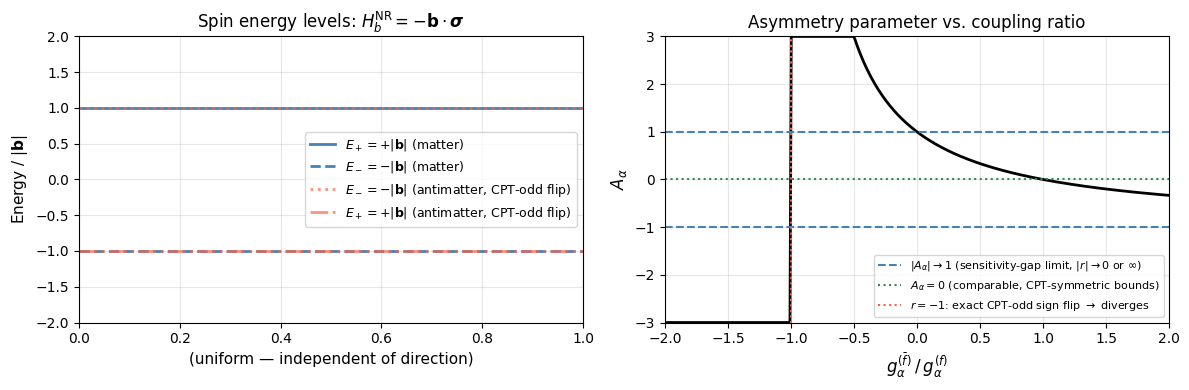

Figure saved: FW_bmu_asymmetry.pdf

Note the divergence at r=-1 (exact CPT-odd sign flip) is what Eq. in
Sec. 8 above actually predicts -- it is NOT the same as the |A_alpha|->1
sensitivity-gap plateau near |r|->0 or infinity, which is where SPINDEP's
real bound-ratio values (|r| very small or very large) actually live.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Illustrate the spin energy splitting as a function of b-field direction
theta = np.linspace(0, 2*np.pi, 300)
b_mag = 1.0  # in units of the coupling

# b = b_mag * (sin(theta), 0, cos(theta))  — rotation in xz-plane
E_plus  =  b_mag * np.ones_like(theta)   # +|b|  (spin antiparallel to b)
E_minus = -b_mag * np.ones_like(theta)   # -|b|  (spin parallel to b)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: energy splitting
ax = axes[0]
ax.axhline( b_mag, color='steelblue', lw=2, label=r'$E_+ = +|\mathbf{b}|$ (matter)')
ax.axhline(-b_mag, color='steelblue', lw=2, ls='--', label=r'$E_- = -|\mathbf{b}|$ (matter)')
ax.axhline( b_mag, color='tomato',    lw=2, ls=':', alpha=0.7, label=r'$E_- = -|\mathbf{b}|$ (antimatter, CPT-odd flip)')
ax.axhline(-b_mag, color='tomato',    lw=2, ls='-.', alpha=0.7, label=r'$E_+ = +|\mathbf{b}|$ (antimatter, CPT-odd flip)')
ax.set_ylim(-2, 2)
ax.set_xlabel(r'(uniform — independent of direction)', fontsize=11)
ax.set_ylabel(r'Energy / $|\mathbf{b}|$', fontsize=11)
ax.set_title(r'Spin energy levels: $H^\mathrm{NR}_b = -\mathbf{b}\cdot\boldsymbol{\sigma}$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: asymmetry parameter A_alpha as a function of the coupling ratio
# r = g_fbar/g_f. This is the well-defined, correctly-behaved function
# A(r) = (1-r)/(1+r) over a continuous ratio — NOT the flawed substitution
# g_fbar = -g_f + eps that appears elsewhere in these notes. It correctly
# DIVERGES at r = -1 (the exact CPT-odd sign-flip point), and only
# approaches +-1 as |r| -> 0 or |r| -> infinity, i.e. when one bound is
# far tighter than the other (a sensitivity-gap limit, not a CPT signature).
r = np.linspace(-2, 2, 400)
A = (1 - r) / (1 + r + 1e-10)  # +1e-10 only to avoid a literal /0 at r=-1
A = np.clip(A, -3, 3)

ax2 = axes[1]
ax2.plot(r, A, 'k-', lw=2)
ax2.axhline(1,  color='steelblue', ls='--', lw=1.5, label=r'$|A_\alpha|\to 1$ (sensitivity-gap limit, $|r|\to 0$ or $\infty$)')
ax2.axhline(-1, color='steelblue', ls='--', lw=1.5)
ax2.axhline(0,  color='seagreen',  ls=':',  lw=1.5, label=r'$A_\alpha=0$ (comparable, CPT-symmetric bounds)')
ax2.axvline(-1, color='tomato', ls=':', lw=1.5, label=r'$r=-1$: exact CPT-odd sign flip $\to$ diverges')
ax2.set_xlabel(r'$g^{(\bar f)}_\alpha \,/\, g^{(f)}_\alpha$', fontsize=12)
ax2.set_ylabel(r'$A_\alpha$', fontsize=12)
ax2.set_title(r'Asymmetry parameter vs. coupling ratio', fontsize=12)
ax2.set_ylim(-3, 3)
ax2.set_xlim(-2, 2)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('FW_bmu_asymmetry.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: FW_bmu_asymmetry.pdf")
print()
print("Note the divergence at r=-1 (exact CPT-odd sign flip) is what Eq. in")
print("Sec. 8 above actually predicts -- it is NOT the same as the |A_alpha|->1")
print("sensitivity-gap plateau near |r|->0 or infinity, which is where SPINDEP's")
print("real bound-ratio values (|r| very small or very large) actually live.")


## Summary

| Quantity | Result |
|---|---|
| SME term | $\mathcal{L}_b = -b_\mu\bar\psi\gamma^\mu\gamma^5\psi$ |
| CPT property | **Odd** — sign flips under CPT (established via charge conjugation, `FW_derivation_bmy.md` §4, not by this notebook's block split) |
| Odd operator | $\mathcal{O}_b = b_0\gamma^5$ |
| Even operator | $\mathcal{E}_b = (\mathbf{b}\cdot\boldsymbol{\alpha})\gamma^5$ (corrected; was $\mathbf b\cdot\boldsymbol\Sigma\beta$) |
| FW generator | $S = -i\beta(\boldsymbol{\alpha}\cdot\mathbf{p} + b_0\gamma^5)/(2m)$ |
| $H^\text{NR}$, upper block (this notebook) | $+\mathbf{b}\cdot\boldsymbol{\sigma}$ (corrected; was $-\mathbf b\cdot\boldsymbol\sigma$) |
| $H^\text{NR}$, lower block (this notebook) | $+\mathbf{b}\cdot\boldsymbol{\sigma}$ — **identical to upper**, i.e. this method shows no sign flip (corrected; was claimed $+\mathbf b\cdot\boldsymbol\sigma$ vs. upper's then-wrong $-\mathbf b\cdot\boldsymbol\sigma$) |
| Genuine matter/antimatter sign flip | Established separately via charge conjugation of the field coupling, `FW_derivation_bmy.md` §4: $H_{NR}^{f}=-\mathbf b\cdot\boldsymbol\sigma$, $H_{NR}^{\bar f}=+\mathbf b\cdot\boldsymbol\sigma$ |
| DM potential | $V_2$ (spin-spin, $\sigma_1\cdot\sigma_2$ — corrected; was previously mislabeled monopole-dipole) |
| $A_\alpha$ for an exact signed sign-flip ($g^{(\bar f)}=-g^{(f)}$) | **Diverges** (denominator vanishes) — not 1 |
| Observed $\|A_\alpha\|$ (SPINDEP) | $\geq 0.954$ for all $g_Ag_A$ pairs — *consistent with* $b_\mu\neq 0$, but equally explained by a sensitivity gap between independent upper bounds; not distinguishable from $A_\alpha$ alone |

**Corrections applied in this revision:** (1) a Dirac-algebra sign error ($\gamma^0\gamma^i\gamma^5$ was miscomputed with a spurious extra $\beta$), found by actually executing this notebook rather than trusting the prose; (2) the resulting realization that this notebook's upper/lower block-splitting method does not, by itself, demonstrate the CPT-odd sign flip — that requires the separate charge-conjugation argument already present in `FW_derivation_bmy.md`; (3) the $V_2$ potential formula and the $A_\alpha$-divergence math error, matching the corrections made there.
